In [ ]:
!pip install jupyter plotly kaleido pandas matplotlib

### This is the beginning of the notebook. We have 5 sections, each will be mixed with code and explaination

## Section 1: Overview

Q1: What is this dataset?

This notebook analyzes a table of recent AI-related book and work records drawn from Open Library. 
Each row describes one cataloged work: title, authors, first publication year, subject tags, languages, publishers, and related metadata. The table is a sample of what Open Library returns when you search for common AI phrases—not a census of every AI book ever published.

Q2: Where did it come from?

The dataset is built by calling the Open Library Search API, a free community-maintained bibliographic database. Nine search strings were ran using the API (for example artificial intelligence, machine learning, generative AI, and large language models).

Q3:  What questions are you trying to answer, and why do those questions matter — to your HCD work, your research interests, or something you genuinely wanted to find out?

I want to know what themes show up in recent AI-related books in Open Library, whether publishing activity is growing or shifting across different AI topics over time, and how much the sample is dominated by English. For me, the point is not counting books for its own sake, but understanding how people might run into AI through a public catalog—what topics get highlighted, what feels current, and who might be included or left out.

This matters to me for a couple of reasons. In HCDE, it’s a real example of learning from what people already put into public systems—like noticing what’s “hot,” but based on catalog data instead of only survey answers. For my own studying, it helps me figure out what to focus on next from what’s actually showing up in the data, not just from headlines. I was also curious whether you can get decent, structured insight from open data if you’re honest about its limits, without always having to pay for big surveys just to start a project.

## Section 2: Data Profile

import data before runnnig operations and interpretation

In [19]:
import pandas as pd

df = pd.read_csv("miniproject_dataset_cleaned.csv", encoding="utf-8")

In [20]:
df.head()

,search_topic,openlibrary_work_key,title,author_name,first_publish_year,publish_years,subjects,languages,edition_count,publishers,publication_places
0,artificial intelligence,/works/OL45003965W,Machine Learning Systems,Vijay Janapa Reddi,2026,2026,NaN,NaN,1,Harvard University,NaN
1,artificial intelligence,/works/OL45009384W,ARTIFICIAL INTELLIGENCE IN EDUCATION,"Dr Subir Sen, Kartik Maji, Dr Mrityunjoy Kaiba...",2026,2026,NaN,NaN,1,Redshine Publication UK,NaN
2,artificial intelligence,/works/OL45031090W,The Dissemination and Evolution of Excellent T...,You Chen,2026,2026,NaN,NaN,1,Scientific Open Access Publishing,NaN
3,artificial intelligence,/works/OL44711065W,Epistémologie de l'IA – New Entry SOTA First I...,Stefano Dorian Franco,2026,2026,Artificial intelligence; Epistemology; Philoso...,NaN,1,Studio SFB creation multimedia / Amazon KDP,NaN
4,artificial intelligence,/works/OL44766535W,The Art Book,Lori Randolph,2026,2026,Modern Art; Graphic arts; Art collections; Art...,NaN,1,Self-Published,NaN


The first rows are recent AI-related works (mostly 2025–2026) with full title and search-topic fields, while some metadata fields (e.g. subjects, languages) are often blank in individual records.

In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 980 entries, 0 to 979
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   search_topic          980 non-null    str  
 1   openlibrary_work_key  980 non-null    str  
 2   title                 980 non-null    str  
 3   author_name           968 non-null    str  
 4   first_publish_year    980 non-null    int64
 5   publish_years         980 non-null    str  
 6   subjects              390 non-null    str  
 7   languages             933 non-null    str  
 8   edition_count         980 non-null    int64
 9   publishers            980 non-null    str  
 10  publication_places    17 non-null     str  
dtypes: int64(2), str(9)
memory usage: 84.3 KB


The table has 980 rows and 11 columns: nine text fields and two integers (first_publish_year, edition_count). 
Most rows have complete basics (topic, title, year), but author, subjects, language, and place are often missing. Publication_places is almost empty, which requires attention for user seeking this information from Open Library database.

In [22]:
df.describe()

,first_publish_year,edition_count
count,980.000000,980.000000
mean,2023.805102,8.046939
std,26.438353,194.299795
min,1200.000000,1.000000
25%,2025.000000,1.000000
50%,2025.000000,1.000000
75%,2025.000000,2.000000
max,2026.000000,6084.000000


Publication years are almost all 2025–2026 (median and quartiles at 2025), with a rare low outlier (1200) dragging the mean to near 2024.

While edition_count is usually 1 (half the rows at 1, 75% at 2 or below) but one extreme value (6084) makes the average (~8) and standard deviation misleading for judging popularity.

In [23]:
df.isnull().sum()

search_topic              0
openlibrary_work_key      0
title                     0
author_name              12
first_publish_year        0
publish_years             0
subjects                590
languages                47
edition_count             0
publishers                0
publication_places      963
dtype: int64

Most columns are complete, subjects (~60%) and publication_places (~98%) have the most gaps, while languages and author_name are missing in only a few rows. Topic- and year-based analysis is unaffected. For analyses that use subjects and languages, I can work with the rows that have those fields, but analyzing publication places is not feasible with this dataset.

## Section 3: Analysis

In [11]:
import plotly.express as px
RECENT_YEAR = 2023
TOP_N = 25

subject_rows = (
    df.dropna(subset=["subjects"])
    .loc[df["first_publish_year"] >= RECENT_YEAR]
    .assign(subject=df["subjects"].str.split("; "))
    .explode("subject")
)

counts = (
    subject_rows["subject"]
    .value_counts()
    .head(TOP_N)
    .reset_index()
)
counts.columns = ["subject", "count"]

row_px = 36
left_px = max(280, int(counts["subject"].str.len().max() * 4.5))

fig = px.bar(
    counts,
    x="count",
    y="subject",
    orientation="h",
    title=f"Top {TOP_N} Open Library subjects (first_publish_year ≥ {RECENT_YEAR})",
)
fig.update_layout(
    height=TOP_N * row_px + 120,
    margin=dict(l=left_px, r=40, t=60, b=40),
    yaxis=dict(categoryorder="total ascending", automargin=True, tickfont=dict(size=10)),
)
fig.update_xaxes(title_text="Number of works")
fig.show()

In [12]:
fig.write_image("chart1_subjects.png", scale=2)

#### Subject frequency (recent AI-related books)

As expected, the most frequent Open Library **subject** tag is **artificial intelligence**—far more often than any other single label. **Technology**, **Education**, and **Science** are also strongly represented. **Education** is third, with **Science**, **computer software**, **computer-assisted instruction**, **Business**, and **human–computer interaction** close behind in the long tail.

**Education** ranking that high is especially interesting: it suggests many recent AI-related works are tied to **learning** and **computer-assisted instruction**. The mix of **computer software**, **business**, and **human–computer interaction** further shows emphasis on **practical applications**, **industry use**, and how **people** relate to **AI systems**.

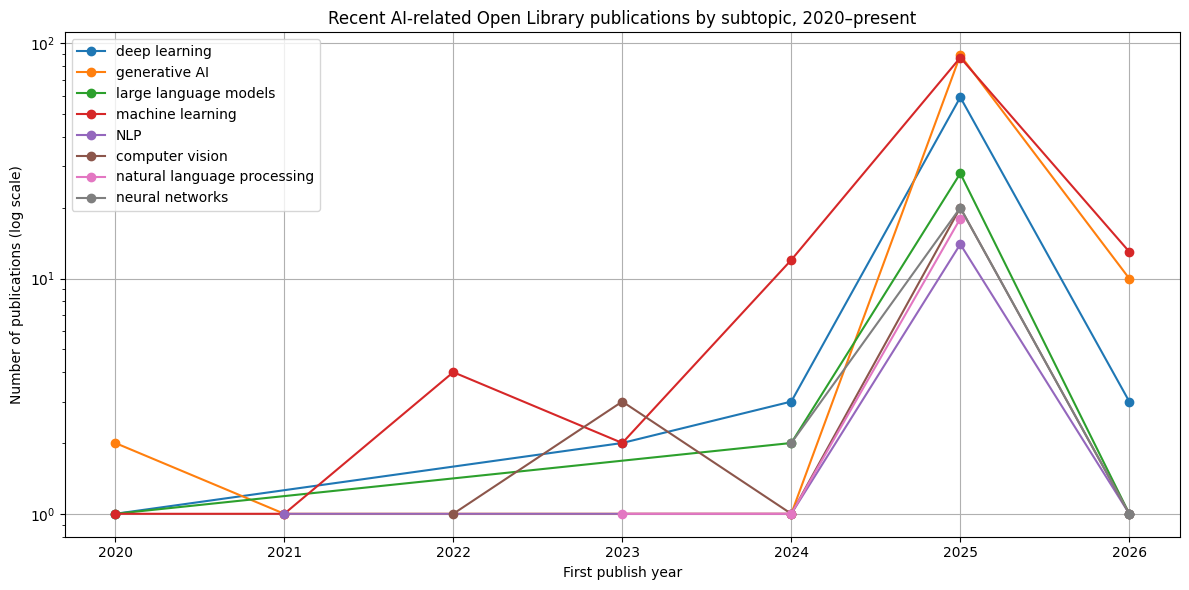

In [17]:
import matplotlib.pyplot as plt
df["first_publish_year"] = pd.to_numeric(df["first_publish_year"], errors="coerce")

df_subtopics = df[df["search_topic"] != "artificial intelligence"].copy()

df_years = df_subtopics[
    df_subtopics["first_publish_year"].notna()
    & (df_subtopics["first_publish_year"] >= 1950)
    & (df_subtopics["first_publish_year"] <= 2026)
].copy()

topic_year_counts = (
    df_years.groupby(["first_publish_year", "search_topic"])
    .size()
    .reset_index(name="publication_count")
)

recent = topic_year_counts[topic_year_counts["first_publish_year"] >= 2020]

plt.figure(figsize=(12, 6))
for topic in recent["search_topic"].unique():
    topic_data = recent[recent["search_topic"] == topic]
    plt.plot(
        topic_data["first_publish_year"],
        topic_data["publication_count"],
        marker="o",
        label=topic,
    )
plt.yscale("log")
plt.title("Recent AI-related Open Library publications by subtopic, 2020–present")
plt.xlabel("First publish year")
plt.ylabel("Number of publications (log scale)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("chart2_publications_2020.png", dpi=150, bbox_inches="tight")
plt.show()

#### AI-related publications over time (Open Library)

The number of AI-related publications in Open Library stays **relatively low before 2020**, with only **scattered** activity across subtopics. After that, the dataset shows a **clear rise** in recent years, especially around **2024** and **2025**.

**Machine learning** and **generative AI** show the **strongest growth**, each peaking in **2025**. **Deep learning** also rises sharply. **Large language models**, **neural networks**, **NLP**, **computer vision**, and **natural language processing** show **smaller but visible** gains.

That pattern suggests recent publishing is **more concentrated** around **newer, high-visibility** areas like **generative AI**, while **machine learning** and **deep learning** remain **heavily represented**.

Since it is only the first quarter of 2026, we do not get the full picture of publications of the year.

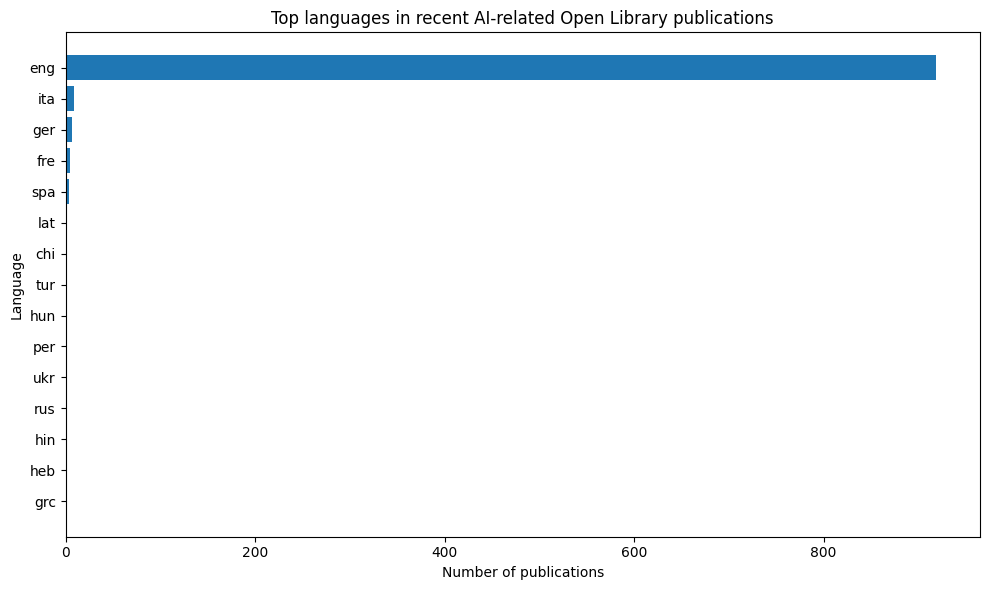

In [18]:
language_counts = (
    df.dropna(subset=["languages"])
    .assign(language=df["languages"].str.split("; "))
    .explode("language")
)

language_counts = (
    language_counts["language"]
    .value_counts()
    .head(15)
    .reset_index()
)
language_counts.columns = ["language", "count"]

plt.figure(figsize=(10, 6))
plt.barh(language_counts["language"], language_counts["count"])
plt.xlabel("Number of publications")
plt.ylabel("Language")
plt.title("Top languages in recent AI-related Open Library publications")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("top_languages.png", dpi=150, bbox_inches="tight")
plt.show()


#### Language distribution (recent AI-related books)
Publications are strongly skewed toward English (eng), at roughly 920 titles—far above every other language in the chart.

The next-largest codes (Italian, German, French, Spanish) each appears a handful amount of times.Several additional codes (Latin, Chinese, Turkish, Hungarian, Persian, Ukrainian, Russian, Hindi, Hebrew, Ancient Greek) appears only a few times (roughly 1–2 or barely visible bars).

This catalog slice is strongly **English-centered**, so it reflects mainstream English-language publishing in Open Library more than a balanced global view. Anyone using this data for “what’s hot in AI” should remember that non-English work is underrepresented here, not absent in the real world.

## Section 4: Conclusions

#### Subject themes
Among recent works that have subject tags, **Artificial intelligence** leads, with **Technology**, **Education**, and **Science** also shows frequently. Followed by tags like software, business, and human–computer interaction. That suggests this slice of AI publishing is not only technical, it often ties to teaching and real-world use. With more time I would do a deeper cleaning of the dataset since some of the category such as agriculture, philosophy and fiction looks unrelated to AI topic, it could be misclassified with their subject label.

#### Publishing over time
Counts stay low before **2020**, then jump in **2024–2025**, with **machine learning** and **generative AI** growing the fastest and **deep learning** close behind. That points to a recent surge centered on newer, high-visibility AI areas, not just slow growth in older topics. With more time I would check whether a few publishers drive the spike and treat **2026** cautiously until the year is complete.

#### Language
**English** makes up almost all works with a language listed; other languages appear only a few times each. So this dataset is a mostly English-language view of AI books in Open Library, not a balanced global sample. With more time I would focus on non-English searches and see what is driving the shape to the English dominated pattern, a possible reason is API is only tagging books with it's own language, so subject of nonEnglish book is tagged in different language.

## Section 5

#### Starting point
I built the dataset with the **Open Library Search API**, running several AI-related search strings and saving metadata to a CSV. 

#### Collection was harder than expected
Long runs were rough: Open Library would **time out**, **reset connections**, or return empty pages if I paged too fast. So my first script used **hard stops**—a max page count per topic and different **row caps per search string**—so a run would finish instead of hanging forever.

#### Week 5: fixed limits (and bias)
Open Library often **timed out** on long runs, so I used **hard caps**: **600 rows** for “artificial intelligence” and **200** for other topics (8 pages each). I got ~1,040 rows quickly, but **“artificial intelligence” dominated** the sample because my rules favored that query—not because the field only looks that way.

#### Week 6: fairer collection
I gave **every topic the same rules**—about **5 minutes each**, retries, and pauses between pages—instead of unequal row caps. Under this rule the comparisons were **more balanced**. I kept the same cleaning and charts (subjects, trends by topic, languages).

#### Surprises & takeaway
**Education** ranked high among other subjects which sounds more related. **generative AI** and **machine learning** jumped after 2020, so even before the most recent AI boom, it became popular already in the year of 2020. Many rows lacked **subjects** or **publication places**, which limited some claims. 